<a href="https://colab.research.google.com/github/Sencer1/pytorch/blob/main/ders2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn

class LinReg(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights = nn.Parameter(torch.randn(1, requires_grad = True, dtype = torch.float))

    self.bias = nn.Parameter(torch.randn(1, requires_grad = True, dtype = torch.float))

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [2]:

torch.manual_seed(42)

model_1 = LinReg()

list(model_1.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [3]:
model_1.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [4]:
x = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = 0.7 * x + 0.3

train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]

x_test, y_test = x[train_split:], y[train_split:]

# print(x_test)
# print("---------------")
# print(y_test)
# print("---------------")
# print(x_train)
# print("---------------")
# print(y_train)

In [5]:
with torch.inference_mode():
  y_preds = model_1(x_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [6]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [7]:
import matplotlib.pyplot as plt

def plot_pred(train_data= x_train, train_label = y_train, test_data = x_test, test_label = y_test, predictions = None):
  plt.figure(figsize=(10, 7))
  plt.scatter(train_data, train_label, c = "b", s = 4 , label = "trainig data")
  label = "training label"
  plt.scatter(test_data, test_label, c = "g", s = 4, label = "testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c = "r", s = 4, label = "predictions")
  plt.legend(prop = {"size": 14});

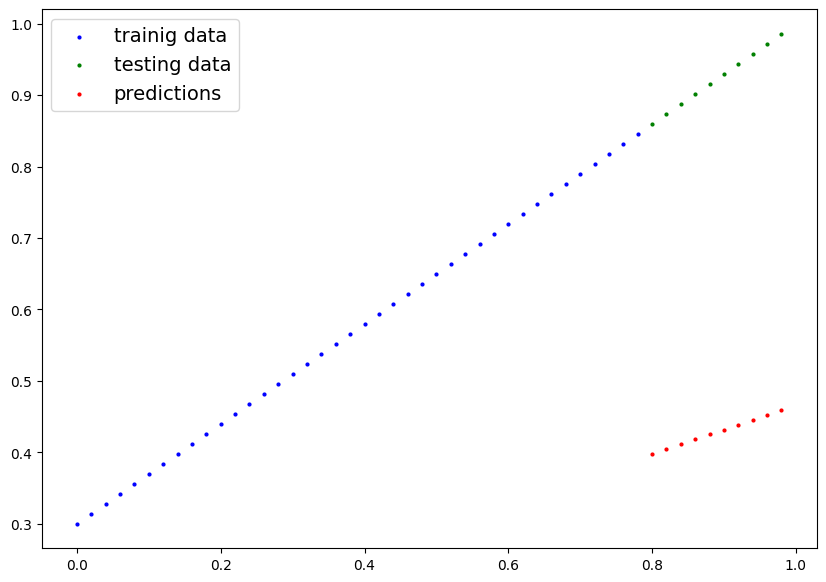

In [8]:
plot_pred(predictions= y_preds)

In [9]:
with torch.no_grad():
  y_preds = model_1(x_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [11]:
model_1.state_dict()
list(model_1.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(model_1.parameters(),
                            lr=0.01)